# 01 · 概念篇：logprob、采样窗、分桶与交叉熵

这个笔记本写给"听说过这些词、但没系统用过"的读者。
目标：读完以后，你能够：

1. 看懂 E2 报告里的每一个数字（`k`、`p_model`、`θ_B`、校准桶……）；
2. 理解"交叉熵（CE）"到底在优化什么，以及它和"轨迹选择"的关系；
3. 亲手跑几段最小模拟，把抽象概念落到可执行代码上。

**本笔记本完全自包含**（只需要 Python + numpy + matplotlib），不读任何项目数据。
真实数据上的完整复现见 `02-实战篇`，更深的口径与选择规则分析见 `03-深挖篇`。

> 术语约定：文中"候选/战术/tactic"都指模型对某个证明状态生成的一段 Lean 战术文本；
> "验证"指把战术喂给 Lean，确认它真的能通过（本项目的实验只把"严格验证通过"当成功）。

In [1]:
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

# 中文字体设置（无该字体时会自动回退，不影响运行）
plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "WenQuanYi Zen Hei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

rng = np.random.default_rng(20261007)
print("环境就绪。numpy:", np.__version__, "/ matplotlib:", matplotlib.__version__)

环境就绪。numpy: 2.5.3 / matplotlib: 3.10.7+dfsg1


---
## 1. 概率、胜率与 log 概率

### 1.1 一个战术的"概率"是什么

语言模型对每个可能的下一个 token 都输出一个概率。把一整段战术文本看作一次"事件"，
它在模型眼里的**单次采样概率**记为 `p`：

- `p = 0.8` 表示"模型 80% 的可能性能吐出这段文本"；
- `p = 1e-6` 表示"百万分之一"。

我们关心的三种概率（E2 报告出现过）：

| 记号 | 含义 | 数据里的字段 |
|---|---|---|
| `p_model` | 采样当时记录的模型概率（先验） | `exp(Σ raw_completion_old_logprobs)` |
| `p_samp` | 采样分布口径下记录的概率 | `exp(Σ raw_completion_sampling_logprobs)` |
| `k / 64` | **经验频率**：64 次采样里实际命中几次 | `canonical.sample_indices` 的长度 |

E2 的核心结论之一就是：`p_model` 在尾部与 `k/64` 严重对不上，所以分析以经验频率为准。

### 1.2 为什么要取对数

两个理由：

1. **数值安全**：一串 token 的概率要连乘，`0.01 × 0.01 × …` 很快下溢到 0；取 log 后变成加法。
2. **可加性**：整段文本的概率 = 每个 token 条件概率之积；取 log 后 = 每 token log 概率之和。

常用刻度是 `-log10(p)`（读作"负 log10 概率"），它有一个很好用的直觉：

- `-log10 = 0` → p = 1（必然）
- `-log10 = 1` → p = 0.1（十中有一）
- `-log10 = 2` → p = 0.01（百里挑一）
- `-log10 = 7.1` → p ≈ 8e-8（约一亿分之一）

下面把这张表打印出来。

In [2]:
def describe(p):
    if p >= 0.5:    return "大概率会发生"
    if p >= 0.1:    return "十有八九"
    if p >= 0.01:   return "百里挑一"
    if p >= 1e-3:   return "千里挑一"
    if p >= 1e-4:   return "万里挑一"
    if p >= 1e-6:   return "百万里挑一"
    return "亿里挑一以下"

print(f"{'p':>12} {'-log10(p)':>10}   直觉说法")
for p in [1.0, 0.5, 0.1, 0.01, 1e-3, 1e-4, 1e-6, 8e-8]:
    print(f"{p:>12.3g} {-math.log10(p):>10.2f}   {describe(p)}")

           p  -log10(p)   直觉说法
           1      -0.00   大概率会发生
         0.5       0.30   大概率会发生
         0.1       1.00   十有八九
        0.01       2.00   百里挑一
       0.001       3.00   千里挑一
      0.0001       4.00   万里挑一
       1e-06       6.00   百万里挑一
       8e-08       7.10   亿里挑一以下


### 1.3 回到 E2

- E2 中成功战术的 `-log10(p_model)` 中位数约 **1.86** → 模型自己认为这些战术是"百里挑一"级别的。
- 最极端的例子（fate_m_009 被选中的战术）：`-log10 = 7.10`。
- 但同一批数据里，它**实际**在 64 次采样中出现了 1 次（频率 1.6%）。

这种"记录值 ≠ 实际频率"的矛盾贯穿整个 E2 报告，第 5 节会解释怎么用"分桶"检查它。

---
## 2. 序列 logprob：把一句话拆成 token

模型生成"`exact curriculum_target`"其实是一步一步的：
先吐 `exact`，再吐 ` curriculum`，再吐 `_target`，最后是结束符。
每一步的概率是**有条件的**（看到前面已经生成的内容之后）。

所以一条长度为 4 的序列：

```text
P(整条) = p1 × p2 × p3 × p4
log P(整条) = log p1 + log p2 + log p3 + log p4
```

数值上验证一下：

In [3]:
tok_probs = [0.99, 0.80, 0.05, 0.999]   # 每个 token 的条件概率（玩具例子）

prod = math.prod(tok_probs)
log_sum = sum(math.log(t) for t in tok_probs)

print("四个 token 的概率:", tok_probs)
print("直接连乘         :", prod)
print("log 相加再取指数 :", math.exp(log_sum))
print("序列 log 概率    :", round(log_sum, 4))
print("换成 -log10      :", round(-log_sum / math.log(10), 4))

四个 token 的概率: [0.99, 0.8, 0.05, 0.999]
直接连乘         : 0.0395604
log 相加再取指数 : 0.03956040000000001
序列 log 概率    : -3.2299
换成 -log10      : 1.4027


### 2.1 数据里的字段

证据包中的每条候选（`policy_requests/*.json` 的 `candidates[i]`）包含：

| 字段 | 含义 |
|---|---|
| `raw_completion_token_ids` | 这条文本的 token 序列 |
| `raw_completion_old_logprobs` | 每个 token 的 log 概率（"old"口径：行为策略） |
| `raw_completion_sampling_logprobs` | 每个 token 的 log 概率（"采样"口径） |

整条战术的序列 logprob = 把相应数组**求和**。

注意两个坑（02/03 会实测）：

1. 数组里可能出现 `0.0`——它**不**意味着"该 token 概率为 1"，更可能是记录方式
   （例如 top-p 截断后部分位置未记录）；
2. 采样用了 `temperature=1.5, top_p=0.9`，而记录值（尤其中间某一步）并不等于
   "这条文本的真实单次采样概率"——E2 第 4 节用真实数据证实了尾部偏差巨大。

结论先记住：**把记录 logprob 当相对参考可以，当绝对概率不行**。

---
## 3. 采样、命中次数 k 与"删失"

"采样 64 次"就是按概率掷 64 次骰子；某个候选被掷中几次，就是它的**命中次数 k**。

真实实验中每个问题的预算是 `B = 64`，最终 E2 统计的就是每个候选的 k。
下面模拟一次，并注意一个关键现象：**k=0 的候选在数据里"不存在"**。

In [4]:
names    = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]
true_p   = np.array([0.45, 0.25, 0.12, 0.08, 0.05, 0.03, 0.015, 0.004, 0.001])
B        = 64

draws = rng.choice(len(true_p), size=B, p=true_p)      # 一次 64 抽
k = np.bincount(draws, minlength=len(true_p))          # 每个候选命中次数

print(f"{'候选':>4} {'真实 p':>9} {'期望命中 64p':>12} {'实际 k':>7} {'频率 k/64':>10}   备注")
for i, name in enumerate(names):
    note = "← 一次都没出现：数据里看不到它" if k[i] == 0 else ""
    print(f"{name:>4} {true_p[i]:>9.4f} {true_p[i]*B:>12.2f} {k[i]:>7d} {k[i]/B:>10.4f}   {note}")

  候选      真实 p     期望命中 64p    实际 k    频率 k/64   备注
   A    0.4500        28.80      30     0.4688   
   B    0.2500        16.00      12     0.1875   
   C    0.1200         7.68       3     0.0469   
   D    0.0800         5.12       9     0.1406   
   E    0.0500         3.20       7     0.1094   
   F    0.0300         1.92       2     0.0312   
   G    0.0150         0.96       1     0.0156   
   H    0.0040         0.26       0     0.0000   ← 一次都没出现：数据里看不到它
   I    0.0010         0.06       0     0.0000   ← 一次都没出现：数据里看不到它


两个要点：

1. **频率不是概率**。`k/64` 只是 64 次里的计数比例；真实 p=0.03 的候选可能恰好出现 0 次或 5 次。
2. **删失（censoring）**：k=0 的候选不会出现在证据里——所以从数据里能看到的每一个候选，
   "频率至少 1/64 ≈ 1.6%"。真实 p 可能远低于 1.6%，只是这波恰好没抽到或恰好抽到一次。
   E2 报告反复强调的"右删失"就是这个意思。

那么 k=1 的候选，它的真实 p 可能是多少？用统计学的**置信区间**回答：
在 64 次里命中 1 次，假设真实概率是 p，我们可以反推"哪些 p 与观测不矛盾"。

In [5]:
def binom_cdf(kmax, n, p):
    """P(X <= kmax)，X ~ Binomial(n, p)"""
    return sum(math.comb(n, i) * p**i * (1 - p)**(n - i) for i in range(0, kmax + 1))

def cp_bounds(k, n, alpha=0.05):
    """Clopper-Pearson 精确置信区间（二分法实现）。"""
    # 下界：找 p 使 P(X >= k) = alpha/2
    lo, hi = 0.0, 1.0
    for _ in range(100):
        mid = (lo + hi) / 2
        if 1 - binom_cdf(k - 1, n, mid) > alpha / 2:
            hi = mid
        else:
            lo = mid
    lower = (lo + hi) / 2
    # 上界：找 p 使 P(X <= k) = alpha/2
    lo, hi = 0.0, 1.0
    for _ in range(100):
        mid = (lo + hi) / 2
        if binom_cdf(k, n, mid) > alpha / 2:
            lo = mid
        else:
            hi = mid
    upper = (lo + hi) / 2
    return lower, upper

lo, hi = cp_bounds(1, 64)
print(f"k=1, B=64 时真实概率 p 的 95% 置信区间：")
print(f"  [{lo:.5f}, {hi:.5f}]  =  [{lo*100:.2f}%, {hi*100:.2f}%]")
print(f"参考：采样窗 θ_B = 3.6%")
print("→ 区间横跨 3.6%，所以单独一个 k=1 的样本，无法判断它'在窗内还是窗外'。")

k=1, B=64 时真实概率 p 的 95% 置信区间：
  [0.00040, 0.08401]  =  [0.04%, 8.40%]
参考：采样窗 θ_B = 3.6%
→ 区间横跨 3.6%，所以单独一个 k=1 的样本，无法判断它'在窗内还是窗外'。


这正是 E2 报告把 k≤2 称为"窗边/窗外（保守分类）"的原因：
单个样本信息量有限，只能靠**集合**（49 条成功、233 条候选）来下结论。

---
## 4. 采样窗 `θ_B = ln(1/δ) / B`

### 4.1 问题

如果一个战术的真实单次采样概率是 `p`，用 `B` 次采样去"找"它，
至少看到一次的概率是多少？

```text
P(至少见一次) = 1 - (1 - p)^B ≈ 1 - e^(-pB)
```

现在反过来：想让"漏掉"的概率不超过 `δ`（例如 10%），需要 p 至少多大？

```text
(1 - p)^B ≤ δ
两边取对数：B × ln(1 - p) ≤ ln(δ)
近似 ln(1 - p) ≈ -p：p ≥ ln(1/δ) / B
```

这就是**采样窗** `θ_B`：**在预算 B 下，"以 1-δ 的把握能被找到"的最低概率线**。

- `B = 64`，`δ = 0.1` → `θ_B = ln(10)/64 ≈ 0.036`，即 **3.6%**；
- 换句话说：p ≥ 3.6% 的战术，64 次里以 90% 把握至少出现一次；p 远低于 3.6% 的战术，"出现与否"基本靠运气。

In [6]:
B_w, delta = 64, 0.1
theta = math.log(1 / delta) / B_w
print(f"δ = {delta}, B = {B_w}  →  θ_B = ln(1/δ)/B = {theta:.4f}  ({theta*100:.2f}%)")
print()
print("不同预算下的窗（δ=0.1）：")
for b in [8, 16, 32, 64, 128, 256]:
    print(f"  B = {b:>3}  →  θ_B = {math.log(1/delta)/b:.3f}  ({math.log(1/delta)/b*100:.1f}%)")

δ = 0.1, B = 64  →  θ_B = ln(1/δ)/B = 0.0360  (3.60%)

不同预算下的窗（δ=0.1）：
  B =   8  →  θ_B = 0.288  (28.8%)
  B =  16  →  θ_B = 0.144  (14.4%)
  B =  32  →  θ_B = 0.072  (7.2%)
  B =  64  →  θ_B = 0.036  (3.6%)
  B = 128  →  θ_B = 0.018  (1.8%)
  B = 256  →  θ_B = 0.009  (0.9%)


/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 33267 (\N{CJK UNIFIED IDEOGRAPH-81F3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23569 (\N{CJK UNIFIED IDEOGRAPH-5C11}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21629 (\N{CJK UNIFIED IDEOGRAPH-547D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) 

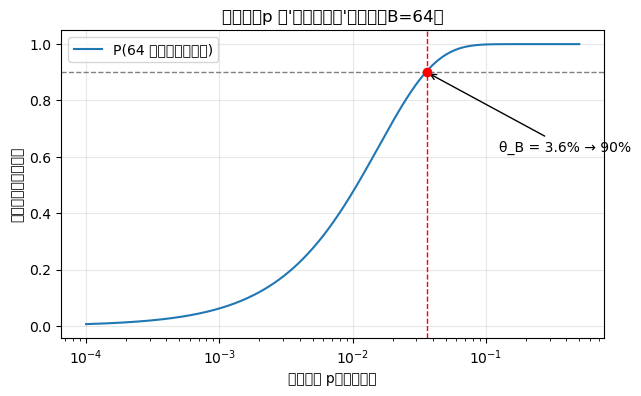

In [7]:
ps = np.logspace(-4, -0.3, 300)
seen = 1 - (1 - ps) ** B_w

plt.figure(figsize=(7, 4))
plt.semilogx(ps, seen, label=f"P(64 次里至少见一次)")
plt.axhline(0.9, color="gray", ls="--", lw=1)
plt.axvline(theta, color="red", ls="--", lw=1)
plt.scatter([theta], [0.9], color="red", zorder=5)
plt.annotate(f"θ_B = {theta*100:.1f}% → 90%", xy=(theta, 0.9),
             xytext=(theta*3.5, 0.62), arrowprops=dict(arrowstyle="->"))
plt.xlabel("真实概率 p（对数轴）")
plt.ylabel("至少命中一次的概率")
plt.title("采样窗：p 与'能否被找到'的关系（B=64）")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

用模拟验证一下"θ_B 处刚好 90%"：

In [8]:
hits = (rng.random((4000, B_w)) < theta).any(axis=1)   # 4000 轮、每轮 64 次
print(f"p=θ_B={theta:.4f} 时，'64 次里至少命中一次'的经验比例 = {hits.mean():.3f}  (理论 0.9)")

p=θ_B=0.0360 时，'64 次里至少命中一次'的经验比例 = 0.899  (理论 0.9)


### 4.2 E2 里的用法

把 `k/64 ≥ θ_B` 作为"窗内"的判定，等价于 `k ≥ 2.3`，也就是 **k ≥ 3**。
E2 结果：49 条成功里只有 **22 条（44.9%）** 在窗内；**27 条（55.1%）** 是 k≤2 的
"窗边/窗外发现"。这就是判据树里"发现瓶颈"分支成立的依据。

再补一个"重发现"直觉：如果 k=1（估计 p≈1/64），同预算（64 次）再跑一波，
重新看到它的概率是：

```text
1 - (1 - 1/64)^64 ≈ 1 - e^(-1) ≈ 63%
```

k=2 时约 87%。也就是说：**只被抽到一次的那些成功，换个随机种子就有约四成会消失**。

In [9]:
for kk in [1, 2, 3, 6, 9]:
    print(f"k={kk:>2}: 同预算再跑一波的重发现概率 ≈ {1 - (1 - kk/64)**64:.3f}")

k= 1: 同预算再跑一波的重发现概率 ≈ 0.635
k= 2: 同预算再跑一波的重发现概率 ≈ 0.869
k= 3: 同预算再跑一波的重发现概率 ≈ 0.954
k= 6: 同预算再跑一波的重发现概率 ≈ 0.998
k= 9: 同预算再跑一波的重发现概率 ≈ 1.000


---
## 5. 分桶（bins）：为什么要分、怎么读

### 5.1 问题

我们想检查：**模型记录的 p 到底准不准？**
数据是（记录 p, 观测频率）一对一的，但 233 个点画散点图很难读；
于是按"记录的 `-log10(p)`"分成若干区间（**桶 / bins**），看每个桶里的观测频率平均值。

如果记录准确，桶里的平均观测频率应该 ≈ 桶对应的 p：

| 桶（记录 -log10 p） | 记录 p 大致范围 | 校准良好时应看到 |
|---|---|---|
| [0, 0.5) | p ≈ 0.3 ~ 1 | 观测频率 ≈ 50%+ |
| [1, 2) | p ≈ 0.01 ~ 0.1 | 观测频率 ≈ 几 % |
| [4+) | p < 1e-4 | 观测频率 ≈ 万分之一，基本看不到 |

### 5.2 一个玩具实验

故意做一个"记录被扭曲"的世界：低先验的候选真实概率其实比记录值高（这正是 E2 里观察到的方向）。
做两组对照：记录=真实（校准良好） vs 记录把稀有低估了（失真）。

In [10]:
rng2 = np.random.default_rng(7)
N = 200
u = np.linspace(0.5, 2.5, N)              # 记录的 -log10 p
recorded = 10.0 ** (-u)
recorded = recorded / recorded.sum()       # 归一化成分布

truth_good = recorded                                  # 情形 1：记录 = 真实
truth_bad  = recorded ** 0.4
truth_bad  = truth_bad / truth_bad.sum()               # 情形 2：稀有被低估（E2 的方向）

def simulate_freq(truth, rounds=4000, B=64, rng=None):
    n = rounds * B
    idx = rng.choice(len(truth), size=n, p=truth)
    cnt = np.bincount(idx, minlength=len(truth))
    return cnt / n

freq_good = simulate_freq(truth_good, rng=rng2)
freq_bad  = simulate_freq(truth_bad,  rng=rng2)

edges = [0, 0.5, 1, 2, 4, 99]
def bucket_table(freq, label):
    print(f"— {label} —")
    print(f"{'桶':>12} {'n':>4} {'记录 p 均值':>12} {'观测频率均值':>12}")
    for e0, e1 in zip(edges[:-1], edges[1:]):
        sel = (u >= e0) & (u < e1)
        if sel.sum() == 0:
            continue
        print(f"{f'[{e0},{e1})':>12} {sel.sum():>4} {recorded[sel].mean():>12.5f} {freq[sel].mean():>12.5f}")
    print()

bucket_table(freq_good, "记录 = 真实（校准良好）")
bucket_table(freq_bad,  "记录低估稀有（失真，类似 E2 观察）")

— 记录 = 真实（校准良好） —
           桶    n      记录 p 均值       观测频率均值
     [0.5,1)   50      0.01385      0.01383
       [1,2)  100      0.00286      0.00287
       [2,4)   50      0.00043      0.00042

— 记录低估稀有（失真，类似 E2 观察） —
           桶    n      记录 p 均值       观测频率均值
     [0.5,1)   50      0.01385      0.00880
       [1,2)  100      0.00286      0.00451
       [2,4)   50      0.00043      0.00219



读法：

- 第一张表：两列大体接近 → 记录可信；
- 第二张表：低先验桶里"观测频率"远大于"记录 p" → **记录系统性低估了尾部**。

### 5.3 E2 的真实桶表

真实数据（233 条 canonical，单波 64 抽样/题）：

```text
桶           n    经验频率均值
[0, 0.5)    22    0.517
[0.5, 1)    12    0.204
[1, 2)      60    0.057
[2, 4)     110    0.021
[4+)        29    0.016     ← p_model < 1e-4，却仍以 ~1/64 出现
```

`[4+)` 桶就是"失真"的证据：如果记录准确，这些候选几乎不该出现。

分桶的两个坑：

1. **桶内样本少时噪声大**（比如 [0.5,1) 只有 12 条）；
2. **删失仍在**：k≥1 的过滤让所有观测频率都不低于 1/64 量级——所以 `[4+)` 的 0.016
   只是"出现的那些的下限"，不是"全部低先验候选的平均频率"。

完整口径讨论见 03 笔记本。

---
## 6. 交叉熵（CE）：模型到底在学什么

### 6.1 定义与直觉

交叉熵衡量"用分布 q 去描述真实分布 p"的代价：

```text
CE(p, q) = -Σᵢ pᵢ · log qᵢ
```

在我们这里，真实分布 `p` 就是"我们希望模型学会的目标"：

- **硬目标（hard target）**：只有一个动作是对的，`p = [1, 0, 0, …]`；
  此时 `CE = -log q[目标]`，即"把目标动作的预测概率提上去"。
- **软目标（soft target）**：把整个访问分布当目标，如 `p = [0.6, 0.3, 0.1]`；
  模型要同时提升多个动作。

为什么优化 CE 等价于"提高正确动作概率"？看单动作情形：
目标概率从 1% 提到 10%，损失从 `-ln(0.01)=4.6` 降到 `-ln(0.1)=2.3`——概率越高，损失越低。

### 6.2 最小可跑演示

一个 3 动作模型（logits → softmax → 概率），用梯度下降优化 CE。

In [11]:
def softmax(z):
    z = np.asarray(z, dtype=float)
    z = z - z.max()
    e = np.exp(z)
    return e / e.sum()

def train_ce(logits0, target, lr=0.5, steps=40):
    """对 logits 做梯度下降；CE 对 logits 的梯度 = q - target。"""
    logits = np.array(logits0, dtype=float)
    target = np.array(target, dtype=float)
    hist = []
    for _ in range(steps):
        q = softmax(logits)
        loss = -np.sum(target * np.log(q))
        logits -= lr * (q - target)
        hist.append((q.copy(), loss))
    return np.array(logits), hist

logits0 = [2.0, 1.0, 0.0]
q0 = softmax(logits0)
print("初始概率:", np.round(q0, 4), " 初始损失:", round(-math.log(q0[0]), 4))
print()

_, hist_hard = train_ce(logits0, [1.0, 0.0, 0.0])
qh, lh = hist_hard[-1]
print("硬目标 [1,0,0] 训练 40 步后：")
print("  概率:", np.round(qh, 4), " 损失:", round(lh, 4))

_, hist_soft = train_ce(logits0, [0.6, 0.3, 0.1])
qs, ls = hist_soft[-1]
print("软目标 [0.6,0.3,0.1] 训练 40 步后：")
print("  概率:", np.round(qs, 4), " 损失:", round(ls, 4))

初始概率: [0.6652 0.2447 0.09  ]  初始损失: 0.4076

硬目标 [1,0,0] 训练 40 步后：
  概率: [0.968  0.0194 0.0127]  损失: 0.0325
软目标 [0.6,0.3,0.1] 训练 40 步后：
  概率: [0.6001 0.3001 0.0998]  损失: 0.8979


/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/a/e2-venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 21516 (\N{CJK UNIFIED IDEOGRAPH-540C}) missing from font(s) 

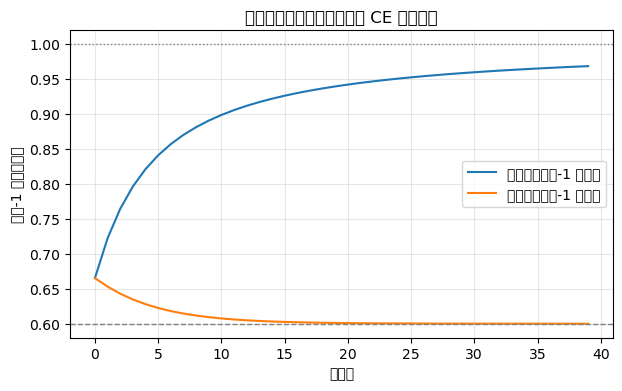

In [12]:
plt.figure(figsize=(7, 4))
plt.plot([q[0] for q, _ in hist_hard], label="硬目标：动作-1 的概率")
plt.plot([q[0] for q, _ in hist_soft], label="软目标：动作-1 的概率")
plt.axhline(1.0, color="gray", ls=":", lw=1)
plt.axhline(0.6, color="gray", ls="--", lw=1)
plt.xlabel("训练步")
plt.ylabel("动作-1 的预测概率")
plt.title("同一初始模型，两种目标的 CE 训练轨迹")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

观察：

- 硬目标把动作-1 一路推向 1.0（推得越猛，对其他动作的"遗忘"越强）；
- 软目标只把动作-1 推到 0.6 附近，同时保留另外两个动作的合理概率。

### 6.3 本项目的 CE

这个项目的主线是 **专家迭代（Expert Iteration）**：

1. 用搜索（MCTS / 大 k 采样）产生大量候选；
2. 用 Lean 严格验证，留下成功轨迹；
3. 选出一条轨迹写成训练样本（transition）；
4. **对这一条轨迹做交叉熵微调**（这就是项目里说的 "CE"，本质是监督式微调 SFT）。

与之对照的 **Online-v2 支线**试图做更"强化学习式"的在线更新（重要性采样、KL 约束），
在 2026-10 的对照实验中因 KL=0.087 > 0.05 被拒——所以当前主线仍是 CE。

一个常见误解："CE 会直接让模型背下这条轨迹吗？"
理论上，CE 只会提高目标动作的概率；是否"吸收"成泛化能力，不保证（见
`2-理论-多样性-可达性-吸收.md`）。E5 实验（软目标 vs 硬目标）正是在测这一点。

**关键连接**：如果目标选的是"稀有变体"（E2 发现：20 条 selected 里 11 条 k≤2），
那么 CE 就在对一条"模型自己都很少采样出来"的轨迹施压——这正是"硬目标 + 稀有选择"
的风险，也是软目标被提议的原因。

---
## 7. 轨迹是怎么被选给 CE 的（本仓库的实测流程）

用 E2 证据包还原出的完整流水线：

```text
① 每题一次策略请求：64 个采样（temperature=1.5, top_p=0.9）
        ↓
② 语义去重（canonical）：64 个原始样本 → 若干"唯一战术"
    （observer 里的 canonical_candidate 事件，sample_indices 记录每次命中的原始样本号）
        ↓
③ 逐条在 Lean 里执行：parse 失败 / 执行失败 / 严格验证通过（verified_proof）
        ↓
④ 搜索选出一条"解出路径"：E2 观测到的规则是
    "评估顺序上第一个通过验证的候选"（20/20 题一致）
        ↓
⑤ 生成 transition（prompt + action + value_target...），写入 transitions.jsonl（本案 20 条）
        ↓
⑥ CE 训练：最大化该 action 的 log 概率（−log π(action|prompt) 最小化）
```

下面的玩具模拟整个流程，并演示一个关键现象：**"第一个通过验证"不等于"最高频"**，
所以同一道题换一波采样，被选中的变体可能不同。

In [13]:
TACTICS   = ["exact curriculum_target", "exact curry_target", "apply curriculum_target"]
TRUE_P    = np.array([0.25, 0.55, 0.20])       # 错误拼写 curry_target 占多数（模仿真实数据）
CAN_VERIFY = {                                  # 只有部分战术能通过 Lean 验证
    "exact curriculum_target": True,
    "exact curry_target": False,
    "apply curriculum_target": True,
}

def toy_wave(seed, B=64):
    r = np.random.default_rng(seed)
    idx = r.choice(len(TACTICS), size=B, p=TRUE_P)
    # ② 去重：按战术文本归组，记录命中的样本位置
    groups = {}
    for pos, i in enumerate(idx):
        groups.setdefault(TACTICS[i], []).append(pos)
    # ④ 评估顺序（E2 观测：按 survivor 样本序号降序；survivor=组内命中的最后一个位置）
    order = sorted(groups, key=lambda t: max(groups[t]), reverse=True)
    # ③ 执行 + 验证；④ 选择"第一个通过验证"
    verified = [t for t in order if CAN_VERIFY[t]]
    selected = verified[0] if verified else None
    return selected, (len(groups[selected]) if selected else 0), {t: len(v) for t, v in groups.items()}

print(f"{'seed':>4} {'选中的战术':<28} {'k':>3} {'频率':>7}   各战术命中数")
for seed in [1, 2, 3, 4, 5, 6, 7, 8]:
    sel, ksel, counts = toy_wave(seed)
    print(f"{seed:>4} {sel!r:<28} {ksel:>3} {ksel/64:>7.3f}   {counts}")

seed 选中的战术                          k      频率   各战术命中数
   1 'exact curriculum_target'     13   0.203   {'exact curry_target': 37, 'apply curriculum_target': 14, 'exact curriculum_target': 13}
   2 'exact curriculum_target'     15   0.234   {'exact curry_target': 37, 'apply curriculum_target': 12, 'exact curriculum_target': 15}
   3 'exact curriculum_target'     14   0.219   {'exact curriculum_target': 14, 'apply curriculum_target': 10, 'exact curry_target': 40}
   4 'apply curriculum_target'     19   0.297   {'apply curriculum_target': 19, 'exact curry_target': 35, 'exact curriculum_target': 10}
   5 'exact curriculum_target'     17   0.266   {'apply curriculum_target': 15, 'exact curry_target': 32, 'exact curriculum_target': 17}
   6 'apply curriculum_target'     16   0.250   {'exact curry_target': 33, 'apply curriculum_target': 16, 'exact curriculum_target': 15}
   7 'exact curriculum_target'     16   0.250   {'exact curry_target': 36, 'apply curriculum_target': 12, 'exact curriculum

你会看到：

- 有时选中的是高频的 `apply curriculum_target`（k 大），有时是稀有的变体（k 小）；
- 选择结果随随机种子变化——**因为"第一个通过验证"依赖评估顺序，而顺序与频率无关**。

真实数据里这一点更明确：20 题中有 **9 题**的选中战术**不是**该题已验证里最高频的变体。
这就是 03 笔记本要复现的"选择规则"分析。

---
## 8. 术语速查表

| 术语 | 一句话解释 | E2 里的位置 |
|---|---|---|
| logprob | 概率的对数；序列 logprob = 每 token logprob 之和 | §2，`raw_completion_*_logprobs` |
| p_model / p_samp | 记录口径的模型概率（先验） | §4 校准表、§3 明细表 |
| k | 64 次采样中的命中次数 | §2 直方图 |
| 经验频率 | `k / 64`，真实概率的有噪声、有删失的估计 | §2、§5 |
| 删失 | k=0 的候选在数据里不可见 → 频率被截断在 1/64 以上 | §7 局限 |
| θ_B | 采样窗 `ln(1/δ)/B`；p ≥ θ_B 才算"有把握被找到" | §2 窗内 22/49 |
| 分桶 / 校准 | 按记录 logprob 分区间，对比观测频率 | §4 表 |
| CE（交叉熵） | 训练损失：压低"目标动作的 −log 概率" | §6 |
| 硬目标 / 软目标 | 目标分布是单选还是访问分布 | §3（selected）、E5 |
| canonical | 去重后的唯一战术（附 `sample_indices`） | §1 规模 |
| transition | 写入训练集的（prompt, action, …）记录 | §3、§7 |
| 专家迭代 | 搜索产生数据 → 验证筛选 → CE 微调的循环 | §6.3 |

## 9. 练习（答案都能在本笔记本里找到）

1. 某个战术记录了 `-log10(p_model) = 3`，它的 `p_model` 是多少？
   （答案：10⁻³ = 0.001）
2. 若把 δ 从 0.1 放宽到 0.2，B=64 的采样窗变成多少？更"紧"还是更"宽"？
   （答案：`ln(5)/64 ≈ 2.5%`——更宽：更多候选能算"有把握被找到"）
3. 为什么"k=1 的成功"不能证明它 p* < θ_B？
   （答案：k=1 的 95% 置信区间 ≈ [0.04%, 8.3%]，横跨 3.6%）
4. 用本笔记本的 `toy_wave`，把 `TRUE_P` 改成 `[0.9, 0.05, 0.05]` 再跑一遍：
   选中稀有的概率变高了还是变低了？为什么？

---

**下一步**：

- `02-实战篇：复现 E2 审计` —— 用真实证据包把报告里每一个数字重算一遍（带图）；
- `03-深挖篇：口径、选择、预算` —— logprob 校准深挖、选择规则核验、预算 what-if。